In [2]:
# !pip install arch

In [3]:
# ============================================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

from arch import arch_model



In [4]:
# ============================================================
# STEP 2: LOAD BRENT DAILY DATASET
# ============================================================

# Change path according to your dataset

brent_daily = pd.read_csv(
    "cleaned_datasets/brent_daily_clean.csv"
)


print(brent_daily.head())

print(brent_daily.info())

         Date  Price
0  1987-05-20  18.63
1  1987-05-21  18.45
2  1987-05-22  18.55
3  1987-05-25  18.60
4  1987-05-26  18.63
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9922 entries, 0 to 9921
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    9922 non-null   object 
 1   Price   9922 non-null   float64
dtypes: float64(1), object(1)
memory usage: 155.2+ KB
None


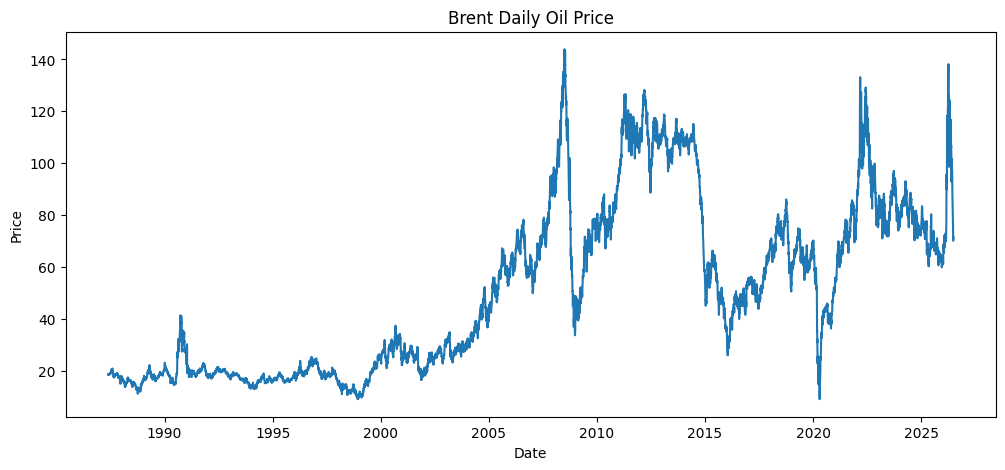

In [5]:
# ============================================================
# STEP 3: DATA PREPROCESSING
# ============================================================


# Convert date column

brent_daily['Date'] = pd.to_datetime(
    brent_daily['Date']
)


# Sort by date

brent_daily = brent_daily.sort_values(
    'Date'
)


# Set date index

brent_daily.set_index(
    'Date',
    inplace=True
)



# Select oil price column
# Change Price if your column name differs

oil_price = brent_daily['Price']



# Plot price series

plt.figure(figsize=(12,5))

plt.plot(
    oil_price
)

plt.title(
    "Brent Daily Oil Price"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Price"
)

plt.show()

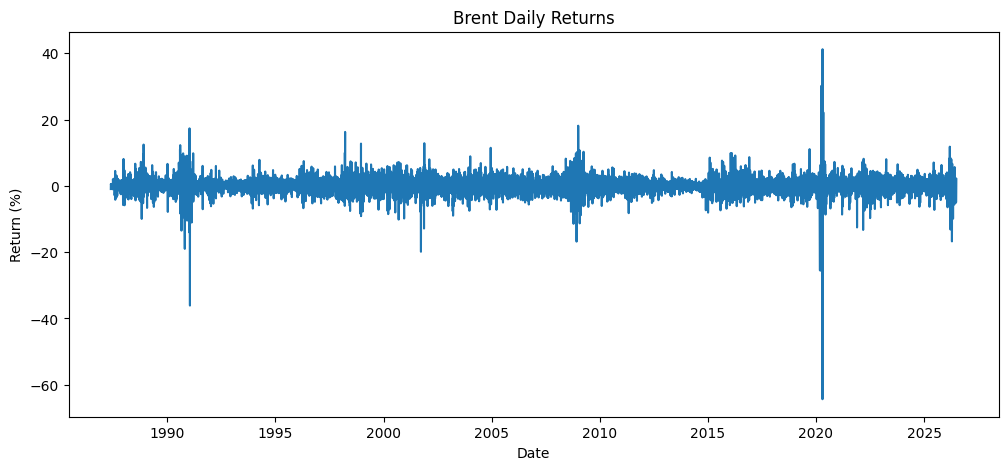

In [6]:
# ============================================================
# STEP 4: CALCULATE DAILY RETURNS
# ============================================================

# GARCH works on returns, not prices

returns = (
    np.log(oil_price)
    .diff()
    .dropna()
)


# Convert to percentage

returns = returns * 100



plt.figure(figsize=(12,5))

plt.plot(
    returns
)

plt.title(
    "Brent Daily Returns"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Return (%)"
)

plt.show()

In [7]:
# ============================================================
# STEP 5: TRAIN TEST SPLIT
# ============================================================

train_size = int(
    len(returns) * 0.8
)


train = returns.iloc[:train_size]

test = returns.iloc[train_size:]


print(
    "Training:",
    train.shape
)

print(
    "Testing:",
    test.shape
)

Training: (7936,)
Testing: (1985,)


In [8]:
# ============================================================
# STEP 6: BUILD GARCH MODEL
# ============================================================


# GARCH(1,1)

garch_model = arch_model(

    train,

    mean='Constant',

    vol='GARCH',

    p=1,

    q=1,

    dist='normal'

)

In [9]:
# ============================================================
# STEP 7: FIT MODEL
# ============================================================


garch_result = garch_model.fit(
    disp='off'
)


print(
    garch_result.summary()
)


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  Price   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -16713.7
Distribution:                  Normal   AIC:                           33435.4
Method:            Maximum Likelihood   BIC:                           33463.4
                                        No. Observations:                 7936
Date:                Wed, Jul 29 2026   Df Residuals:                     7935
Time:                        22:26:19   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0296  1.985e-02      1.490      0.136 

In [10]:
# ============================================================
# STEP 8: FORECAST VOLATILITY
# ============================================================


forecast = garch_result.forecast(

    horizon=len(test),

    reindex=False

)



# Extract variance forecast

variance_forecast = forecast.variance.values[-1]



# Convert variance to volatility

volatility_forecast = np.sqrt(
    variance_forecast
)



# Create dataframe

volatility_df = pd.DataFrame(

    {
        "Actual_Return": test.values,

        "Forecast_Volatility": volatility_forecast

    },

    index=test.index

)



print(
    volatility_df.head()
)


            Actual_Return  Forecast_Volatility
Date                                          
2018-08-27       0.000000             1.613522
2018-08-28       1.995809             1.620670
2018-08-29       0.210554             1.627764
2018-08-30       1.280059             1.634804
2018-08-31      -0.142866             1.641792


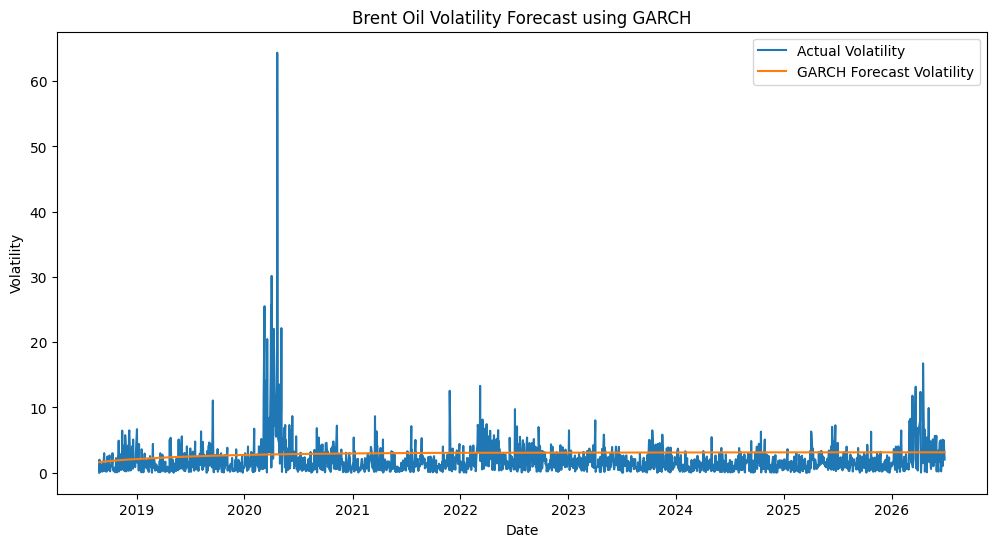

In [11]:
# ============================================================
# STEP 9: VISUALIZE VOLATILITY FORECAST
# ============================================================


plt.figure(figsize=(12,6))


plt.plot(

    volatility_df.index,

    np.abs(volatility_df['Actual_Return']),

    label="Actual Volatility"

)


plt.plot(

    volatility_df.index,

    volatility_df['Forecast_Volatility'],

    label="GARCH Forecast Volatility"

)



plt.title(
    "Brent Oil Volatility Forecast using GARCH"
)


plt.xlabel(
    "Date"
)


plt.ylabel(
    "Volatility"
)


plt.legend()

plt.show()

In [12]:
# ============================================================
# STEP 10: EVALUATE GARCH PERFORMANCE
# ============================================================


# Actual volatility approximation

actual_volatility = np.abs(
    test.values
)



predicted_volatility = (
    volatility_forecast
)



# MAE

mae = mean_absolute_error(

    actual_volatility,

    predicted_volatility

)



# RMSE

rmse = np.sqrt(

    mean_squared_error(

        actual_volatility,

        predicted_volatility

    )

)



# MAPE

mape = np.mean(

    np.abs(

        (
            actual_volatility -
            predicted_volatility
        )
        /
        actual_volatility

    )

) * 100



print("==============================")
print("GARCH MODEL PERFORMANCE")
print("==============================")


print(
    "MAE:",
    mae
)


print(
    "RMSE:",
    rmse
)


print(
    "MAPE:",
    mape,
    "%"
)




GARCH MODEL PERFORMANCE
MAE: 1.920921313859714
RMSE: 2.980009891419627
MAPE: inf %


C:\Users\ranpa\AppData\Local\Temp\ipykernel_17220\473934237.py:54: RuntimeWarning: divide by zero encountered in divide
  (


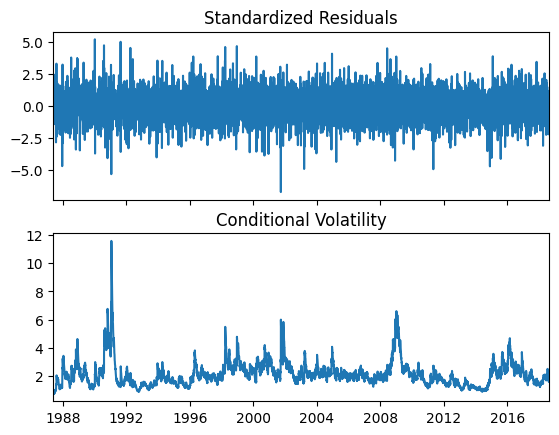

In [13]:
# ============================================================
# STEP 11: MODEL DIAGNOSTICS
# ============================================================


# Plot residual diagnostics

garch_result.plot()

plt.show()

In [14]:
# ============================================================
# STEP 12: SAVE MODEL
# ============================================================


import pickle


with open(
    "brent_daily_garch_model.pkl",
    "wb"
) as file:

    pickle.dump(
        garch_result,
        file
    )


print(
    "GARCH model saved successfully!"
)

GARCH model saved successfully!
